In [240]:
import tensorflow as tf

In [241]:
# Data Pre-processing
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

data_path = tf.keras.utils.get_file(origin=_URL,  cache_dir="." ,fname="cat_vs_dogs", extract=True)


In [242]:
from pathlib import Path

data_path = Path(data_path)

data_path = data_path/"cats_and_dogs_filtered"

data_path

train_data = data_path/"train"
val_data = data_path/"validation"

In [243]:
# Create td.data Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(directory=train_data, validation_split=0.2, batch_size=32, subset="training", seed=42, shuffle=True, image_size=IMAGE_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(directory=val_data, validation_split=0.2, subset="validation", batch_size=32, seed=42, image_size=IMAGE_SIZE)



Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


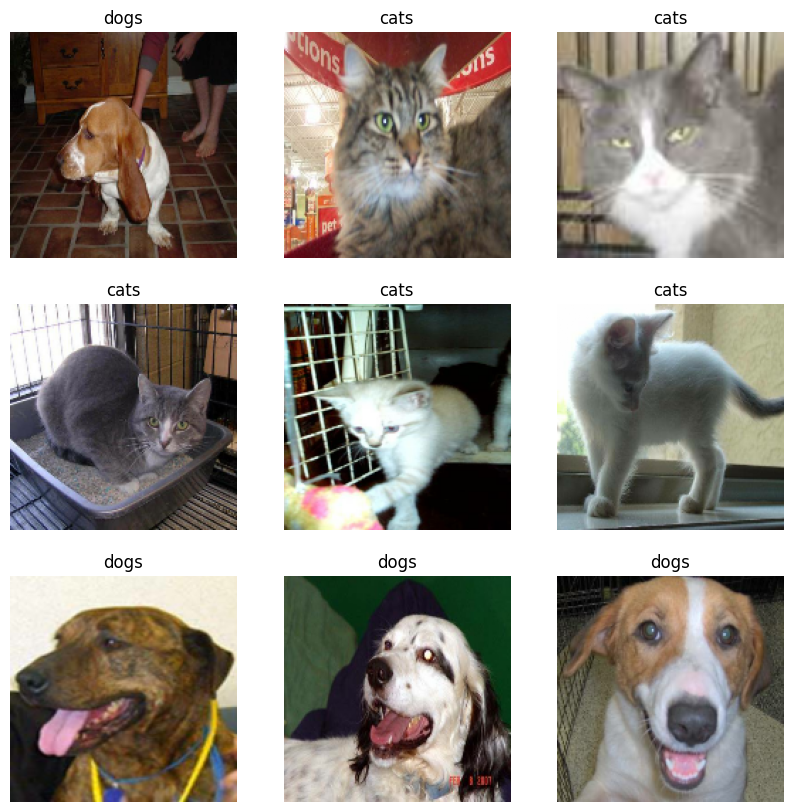

In [244]:
IMAGE_SIZE = (160,160)

class_names = train_ds.class_names

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(img[i]/255.0)
        plt.title(class_names[label[i]])
        plt.axis("off")
    



In [245]:
class_names

['cats', 'dogs']

In [249]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))

Number of validation batches: 6
Number of train batches: 50


In [247]:
val_batchs = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batchs // 5)
val_ds = val_ds.skip(val_batchs // 5)


In [250]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

Number of validation batches: 6
Number of train batches: 50
Number of test batches: 1


In [255]:
## performnce
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [256]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2)
])

In [257]:
data_augmentation

<Sequential name=sequential_3, built=False>

In [258]:
for image,_ in train_ds.take(1):
    test_img = image[0]

In [259]:
test_img

<tf.Tensor: shape=(160, 160, 3), dtype=float32, numpy=
array([[[  9.4625   ,  23.4625   ,   1.9812499],
        [ 20.721874 ,  34.351562 ,  11.684374 ],
        [  8.4921875,  21.257812 ,   6.6640625],
        ...,
        [  2.265625 ,   9.1171875,   9.3515625],
        [  3.259369 ,  16.296844 ,  15.037476 ],
        [  6.259384 ,  24.142204 ,  22.895332 ]],

       [[ 30.315624 ,  44.192184 ,  20.932812 ],
        [ 17.832813 ,  30.9625   ,  12.554687 ],
        [ 12.6328125,  22.875    ,  11.8671875],
        ...,
        [  2.265625 ,  10.296875 ,   3.8828125],
        [  1.       ,  14.129684 ,   5.3703156],
        [  1.       ,  14.123436 ,   5.753128 ]],

       [[ 19.221874 ,  31.721874 ,  15.845312 ],
        [ 27.110937 ,  39.240623 ,  25.592188 ],
        [ 20.03125  ,  31.796875 ,  21.734375 ],
        ...,
        [  5.9921875,  17.375    ,   3.7578125],
        [  1.6296844,  12.407791 ,   1.0187378],
        [  4.259384 ,  20.271896 ,   7.7718964]],

       ...,

     

In [265]:
tf.reduce_max(test_img)

<tf.Tensor: shape=(), dtype=float32, numpy=247.11563110351562>

In [270]:
process_inp = tf.keras.applications.mobilenet_v2.preprocess_input


new_img = process_inp(test_img)
new_img

<tf.Tensor: shape=(160, 160, 3), dtype=float32, numpy=
array([[[-0.92578435, -0.8159804 , -0.9844608 ],
        [-0.8374755 , -0.730576  , -0.90835786],
        [-0.9333946 , -0.83327204, -0.94773287],
        ...,
        [-0.98223037, -0.92849267, -0.9266544 ],
        [-0.97443634, -0.8721816 , -0.88205904],
        [-0.9509068 , -0.8106494 , -0.8204287 ]],

       [[-0.7622304 , -0.65339464, -0.8358211 ],
        [-0.8601348 , -0.75715685, -0.9015319 ],
        [-0.90091914, -0.82058823, -0.906924  ],
        ...,
        [-0.98223037, -0.9192402 , -0.96954656],
        [-0.99215686, -0.88917893, -0.9578799 ],
        [-0.99215686, -0.889228  , -0.95487744]],

       [[-0.8492402 , -0.751201  , -0.87572306],
        [-0.7873652 , -0.6922304 , -0.79927695],
        [-0.84289217, -0.75061274, -0.8295343 ],
        ...,
        [-0.95300245, -0.8637255 , -0.97052693],
        [-0.98721814, -0.902684  , -0.9920099 ],
        [-0.9665931 , -0.8410047 , -0.93904394]],

       ...,

     

In [273]:
tf.reduce_min(new_img)

<tf.Tensor: shape=(), dtype=float32, numpy=-1.0>

In [274]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False)

In [275]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [278]:
image_batch, label_batch = next(iter(train_ds))

image_batch.shape

feature_batch = base_model(image_batch)

In [280]:
feature_batch.shape

TensorShape([32, 5, 5, 1280])

In [281]:
!pip install mlflow

301410.21s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached gunicorn-23.0.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached google_auth-2.40.3-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached starlette-0.46.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━

In [284]:
!mlflow ui

301456.35s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[2025-06-30 09:53:42 +0530] [63237] [INFO] Starting gunicorn 23.0.0
[2025-06-30 09:53:42 +0530] [63237] [INFO] Listening at: http://127.0.0.1:5000 (63237)
[2025-06-30 09:53:42 +0530] [63237] [INFO] Using worker: sync
[2025-06-30 09:53:42 +0530] [63238] [INFO] Booting worker with pid: 63238
[2025-06-30 09:53:42 +0530] [63239] [INFO] Booting worker with pid: 63239
[2025-06-30 09:53:42 +0530] [63240] [INFO] Booting worker with pid: 63240
[2025-06-30 09:53:42 +0530] [63241] [INFO] Booting worker with pid: 63241
^C
[2025-06-30 09:59:56 +0530] [63237] [INFO] Handling signal: int
[2025-06-30 09:59:57 +0530] [63240] [INFO] Worker exiting (pid: 63240)
[2025-06-30 09:59:57 +0530] [63239] [INFO] Worker exiting (pid: 63239)
[2025-06-30 09:59:57 +0530] [63241] [INFO] Worker exiting (pid: 63241)
[2025-06-30 09:59:57 +0530] [63238] [INFO] Worker exiting (pid: 63238)
